In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

plt.style.use("ggplot")

In [2]:
df = pd.read_csv(
    "../data/processed/reddit_posts_cleaned.csv"
)

text = (
    df["keyword"].fillna("") +
    " " +
    df["clean_title"].fillna("")
)

In [3]:
vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=1500
)

X = vectorizer.fit_transform(text)

In [4]:
kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df["cluster"] = kmeans.fit_predict(X)

df.head()

,keyword,title,subreddit,timestamp,post_url,scrape_date,batch_number,source,clean_title,location,skill,role,cluster
0,developersindia hiring,How's Infosys for starters 😳,r/IndiaTech,2026-03-10T07:42:32+00:00,https://old.reddit.com/r/IndiaTech/comments/1r...,NaN,NaN,NaN,hows infosys for starters,Unknown,Unknown,Software Engineer,0
1,developersindia hiring,Who's hiring? - Monthly Megathread - June 2026,r/developersIndia,2026-06-01T04:32:05+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread june 2026,Unknown,Unknown,Software Engineer,0
2,developersindia hiring,Who's hiring? - Monthly Megathread - February ...,r/developersIndia,2026-02-01T04:32:29+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread february 2026,Unknown,Unknown,Software Engineer,0
3,developersindia hiring,Who's looking for work? - Monthly Megathread -...,r/developersIndia,2026-06-01T04:30:14+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos looking for work monthly megathread june ...,Unknown,Unknown,Software Engineer,0
4,developersindia hiring,Who's hiring? - Monthly Megathread - May 2026,r/developersIndia,2026-05-01T04:32:13+00:00,https://old.reddit.com/r/developersIndia/comme...,NaN,NaN,NaN,whos hiring monthly megathread may 2026,Unknown,Unknown,Software Engineer,0


# Graph 1 — Cluster Distribution

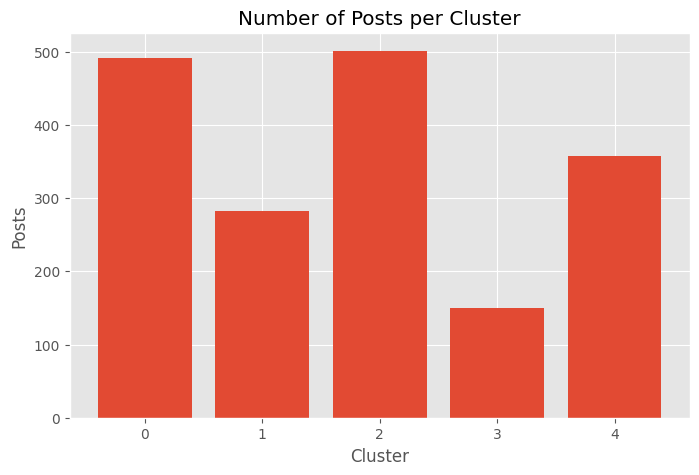

In [5]:
cluster_counts = df["cluster"].value_counts().sort_index()

plt.figure(figsize=(8,5))

plt.bar(
    cluster_counts.index.astype(str),
    cluster_counts.values
)

plt.title("Number of Posts per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Posts")

plt.show()

# Graph 2 — Elbow Method

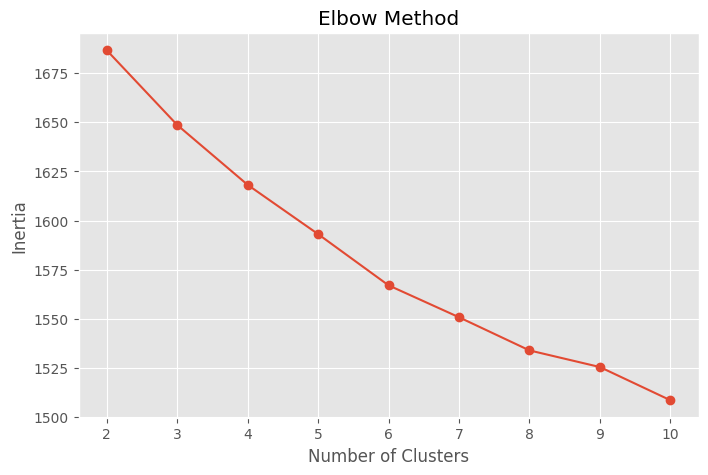

In [6]:
inertia = []

for k in range(2,11):

    model = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    model.fit(X)

    inertia.append(model.inertia_)

plt.figure(figsize=(8,5))

plt.plot(
    range(2,11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters")

plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

# Graph 3 — PCA Visualization

pca = PCA(n_components=2)

reduced = pca.fit_transform(
    X.toarray()
)

plt.figure(figsize=(9,7))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=df["cluster"]
)

plt.title("PCA Visualization of Reddit Post Clusters")

plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")

plt.show()

# Step 5 — Interpret the Clusters

In [9]:
terms = vectorizer.get_feature_names_out()

order_centroids = kmeans.cluster_centers_.argsort()[:, ::-1]

for i in range(5):

    print("="*50)
    print(f"Cluster {i}")

    top_words = []

    for ind in order_centroids[i, :10]:
        top_words.append(terms[ind])

    print(", ".join(top_words))

Cluster 0
hiring, 2026, infosys, accenture, cognizant, campus, developersindia, tcs, amazon, wipro
Cluster 1
engineer, software, remote, india, learning, machine, ai, devops, hiring, bangalore
Cluster 2
developer, india, internship, remote, python, software, web, development, stack, summer
Cluster 3
data, analyst, india, scientist, business, remote, hyderabad, engineer, big, job
Cluster 4
jobs, job, india, mumbai, ahmedabad, kolkata, noida, pune, gurgaon, delhi


In [10]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X, df["cluster"])

print(f"Silhouette Score: {score:.3f}")

Silhouette Score: 0.038
